In [1]:
# SimPEG functionality
from simpeg.potential_fields import gravity
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

# discretize functionality
from discretize import TensorMesh, TreeMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

mpl.rcParams.update({"font.size": 14})

In [2]:
# URL to download from repository assets
data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/03-gravity/inv_gravity_anomaly_3d_files.tar.gz"

# download the data
downloaded_data = download(data_source, overwrite=True)

# unzip the tarfile
tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()

# path to the directory containing our data
dir_path = downloaded_data.split(".")[0] + os.path.sep

# files to work with
topo_filename = dir_path + "gravity_topo.txt"
data_filename = dir_path + "gravity_data.obs"

overwriting c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Tutorial\inv_gravity_anomaly_3d_files.tar.gz
   saved to: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Tutorial\inv_gravity_anomaly_3d_files.tar.gz
Download completed!


In [3]:
# Load topography (xyz file)
topo_xyz = np.loadtxt(str(topo_filename))

# Load field data (xyz file)
dobs_xyz = np.loadtxt(str(data_filename))

print("Topography data shape:", topo_xyz.shape)
print("Field data shape:", dobs_xyz.shape)

Topography data shape: (1681, 3)
Field data shape: (289, 4)


In [4]:
# Define receiver locations and observed data
receiver_locations = dobs_xyz[:, 0:3] # first three column: x y z
dobs = dobs_xyz[:, -1] # last column: observed gravity data

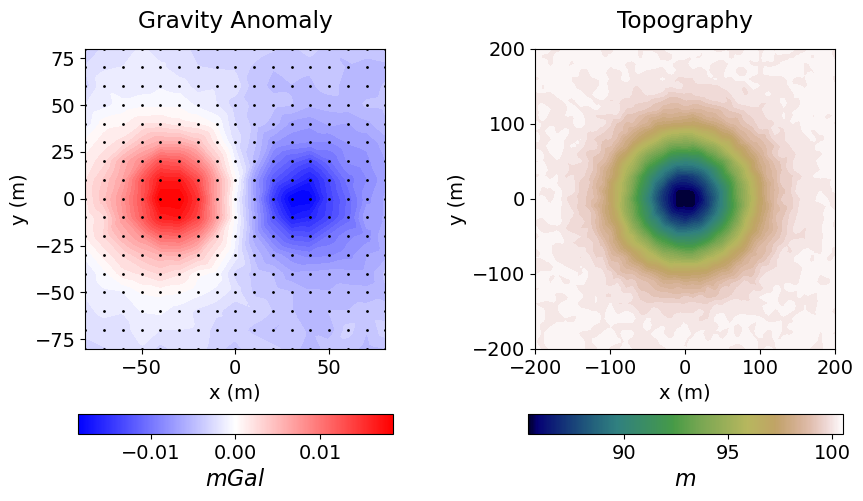

In [5]:
fig = plt.figure(figsize=(9, 5))

ax1 = fig.add_axes([0.05, 0.35, 0.35, 0.6])
plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    dataloc=True, # show data locations
    ncontour=40,
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Gravity Anomaly", pad=15)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

cx1 = fig.add_axes([0.05, 0.18, 0.35, 0.04])
norm1 = mpl.colors.Normalize(vmin=-np.max(np.abs(dobs)), vmax=np.max(np.abs(dobs)))
cbar1 = mpl.colorbar.ColorbarBase(
    cx1, norm=norm1, orientation="horizontal", cmap=mpl.cm.bwr
)
cbar1.set_label("$mGal$", size=16)

ax2 = fig.add_axes([0.55, 0.35, 0.35, 0.6])
plot2Ddata(
    topo_xyz[:, 0:2],
    topo_xyz[:, -1],
    ax=ax2,
    ncontour=50,
    contourOpts={"cmap": "gist_earth"},
)
ax2.set_title("Topography", pad=15)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

cx2 = fig.add_axes([0.55, 0.18, 0.35, 0.04])
norm2 = mpl.colors.Normalize(vmin=np.min(topo_xyz[:, -1]), vmax=np.max(topo_xyz[:, -1]))
cbar2 = mpl.colorbar.ColorbarBase(
    cx2, norm=norm2, orientation="horizontal", cmap=mpl.cm.gist_earth
)
cbar2.set_label("$m$", size=16)

plt.show()

## Assign uncertatinty

In [6]:
maximum_anomaly = np.max(np.abs(dobs))
floor_uncertainty = 0.02 * maximum_anomaly
uncertainties = floor_uncertainty * np.ones(np.shape(dobs))
print("Floor uncertainty: {}".format(floor_uncertainty))

Floor uncertainty: 0.00037204


## Survey

In [7]:
# Define the receivers. The data consist of vertical gravity anomaly measurements.
# The set of receivers must be defined as a list.
receiver_list = gravity.receivers.Point(receiver_locations, components="gz")
receiver_list = [receiver_list]

# Define the source field
source_field = gravity.sources.SourceField(receiver_list=receiver_list)

# Define the survey
survey = gravity.survey.Survey(source_field)

In [8]:
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

## Weighted Least-Squares Inversion on a Tensor Mesh

In [9]:
# Generate tensor mesh with top at z = 0 m
dh = 5.0  # minimum cell size
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]  # discretization along x
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]  # discretization along y
hz = [(dh, 5, -1.3), (dh, 15)]  # discretization along z
tensor_mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
tensor_mesh.origin += np.r_[0.0, 0.0, topo_xyz[:, -1].max()]

In [10]:
# Define the Active Cells
active_tensor_cells = active_from_xyz(tensor_mesh, topo_xyz)
n_tensor_active = int(active_tensor_cells.sum())

In [11]:
# Mapping from the Model to Active Cells
tensor_model_map = maps.IdentityMap(nP=n_tensor_active)

Starting/Reference Models

In [12]:
starting_tensor_model = 1e-6 * np.ones(n_tensor_active)
reference_tensor_model = np.zeros_like(starting_tensor_model)

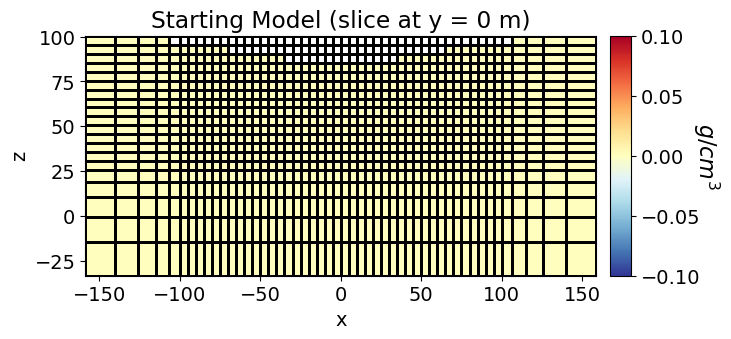

In [13]:
# Map for ignoring inactive cells when plotting
tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_tensor_cells, np.nan)


fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=-0.1, vmax=0.1)
tensor_mesh.plot_slice(
    tensor_plotting_map * starting_tensor_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title("Starting Model (slice at y = 0 m)")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

Forward simulation

In [14]:
simulation_L2 = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    rhoMap=tensor_model_map,
    active_cells=active_tensor_cells,
    engine="choclo",
)

Data misfit

In [15]:
dmis_L2 = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_L2)

Regularization

In [16]:
reg_L2 = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_tensor_cells,
    length_scale_x=1.0, # smoothness in x direction 如果有地质先验，比如层状构造往往垂向变化比水平变化更剧烈，那有时会把不同方向设成不同值。
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_tensor_model, # zero reference model
    reference_model_in_smooth=False, #参考模型只用于 smallness 项，不用于 smoothness 项
)

Optimization

In [17]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

Inverse Problem

In [18]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

Directives

In [19]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

Define and Run the Inversion

In [20]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run inversion
recovered_tensor_model = inv_L2.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 289.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  8.15e+03  5.58e+04  6.08e-07  5.58e+04                                 
   1  8.15e+03  2.20e+04  1.28e+00  3.24e+04    2.09e+05      0              
   2  4.08e+03  1.46e+04  2.57e+00  2.51e+04    4.96e+04      0              
   3  2.04e+03  8.59e+03  4.67e+00  1.81e+04    3.70e+04      0              
   4  1.02e+03  4.44e+03  7.52e+00  1.21e+04    2.62e+04      0              
   5  5.10e+02  2.07e+03  1.07e+01  7.55e+03    1.73e+04      0              
   6  2.55e+02  9.39e+02  1.38e+01  4.46e+03    1.07e+04      0              
   7  1.27e+02  4.54e+02  1.64e+01  2.55e+03    6.22e+03      0              
   8  6.37e+01  2.52e+02  1.86e+01  1.44e+03    3.49e+03      0              
------------------------- STOP! -------------------------
1 : |

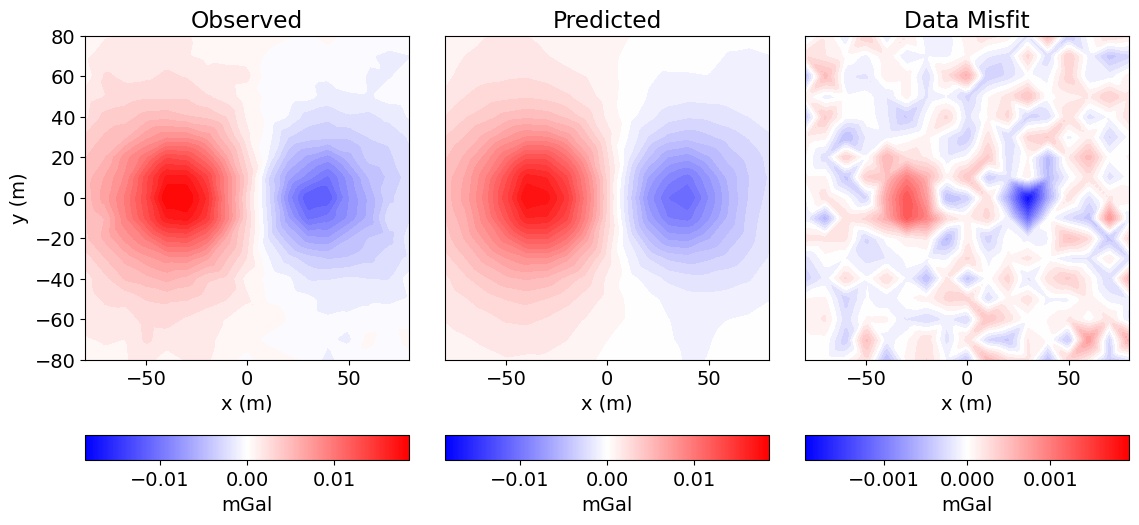

In [21]:
# Predicted data with final recovered model.
dpred = inv_prob_L2.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred, dobs - dpred]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["mGal", "mGal", "mGal"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].ax.locator_params(nbins=3)
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

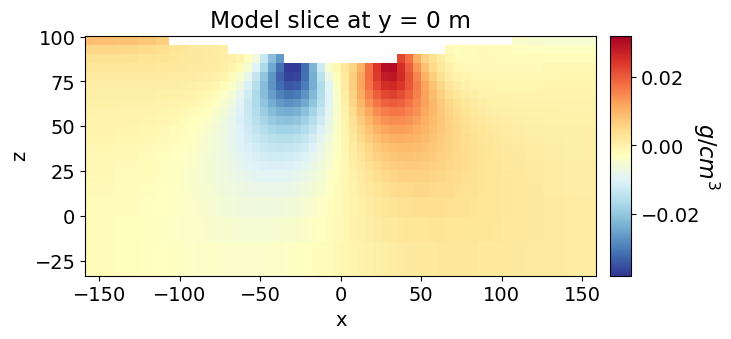

In [22]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_tensor_model), vmax=np.max(recovered_tensor_model)
)
tensor_mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

## Iteratively Re-weighted Least-Squares (IRLS) Inversion on a Tree Mesh

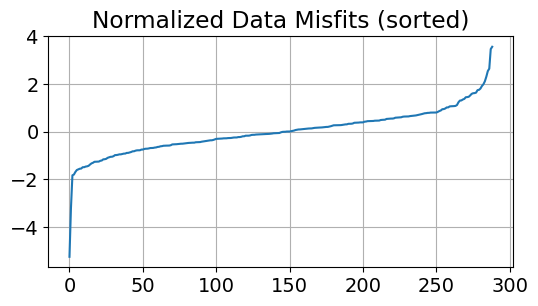

In [23]:
# Compute normalized data misfits
normalized_data_misfits = (dobs - dpred) / uncertainties


# Plot the normalized data misfits
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)
ax.plot(np.sort(normalized_data_misfits))
ax.set_title("Normalized Data Misfits (sorted)")
ax.grid()
plt.show(fig)

In [24]:
# Generate new uncertainties
new_uncertainties = uncertainties.copy()

uncertainty_reduce_factor = 2.5
new_uncertainties[np.abs(normalized_data_misfits) > 2.0] /= uncertainty_reduce_factor # reduce uncertainty for data points with large misfits by a factor of 2.5

In [25]:
# Generate new data object
new_data_object = data.Data(survey, dobs=dobs, standard_deviation=new_uncertainties)

# Tree mesh

In [26]:
dx = 5  # minimum cell width (base tree_mesh cell width) in x
dy = 5  # minimum cell width (base tree_mesh cell width) in y
dz = 5  # minimum cell width (base tree_mesh cell width) in z

x_length = 240.0  # domain width in x
y_length = 240.0  # domain width in y
z_length = 120.0  # domain width in z

# Compute number of base tree_mesh cells required in each direction, rounded to the nearest power of 2
nbcx = 2 ** int(np.round(np.log(x_length / dx) / np.log(2.0)))
nbcy = 2 ** int(np.round(np.log(y_length / dy) / np.log(2.0)))
nbcz = 2 ** int(np.round(np.log(z_length / dz) / np.log(2.0)))

# Define the base tree_mesh
hx = [(dx, nbcx)]
hy = [(dy, nbcy)]
hz = [(dz, nbcz)]
tree_mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# Shift vertically to top same as maximum topography
tree_mesh.origin += np.r_[0.0, 0.0, topo_xyz[:, -1].max()]

# Refine based on surface topography
tree_mesh.refine_surface(topo_xyz, padding_cells_by_level=[2, 2], finalize=False) # refine the tree mesh based on the surface topography, with 2 padding cells at each level of refinement, and do not finalize yet to allow for further refinements

# Refine box based on region of interest
wsb_corner = np.c_[-100, -100, 20]
ent_corner = np.c_[100, 100, 100]
# Note -1 is a flag for smallest cell size
tree_mesh.refine_box(wsb_corner, ent_corner, levels=[-1], finalize=False) # refine the tree mesh within a box defined by the corners wsb_corner and ent_corner, with refinement level -1 (smallest cell size), and do not finalize yet to allow for further refinements

tree_mesh.finalize()

Define the Active Cells

In [27]:
active_tree_cells = active_from_xyz(tree_mesh, topo_xyz)
n_tree_active = int(active_tree_cells.sum())

Mapping from Model to Active Cells

In [28]:
tree_model_map = maps.IdentityMap(nP=n_tree_active)

Starting and Reference Models

In [29]:
starting_tree_model = 1e-6 * np.ones(n_tree_active)
reference_tree_model = np.zeros_like(starting_tree_model)

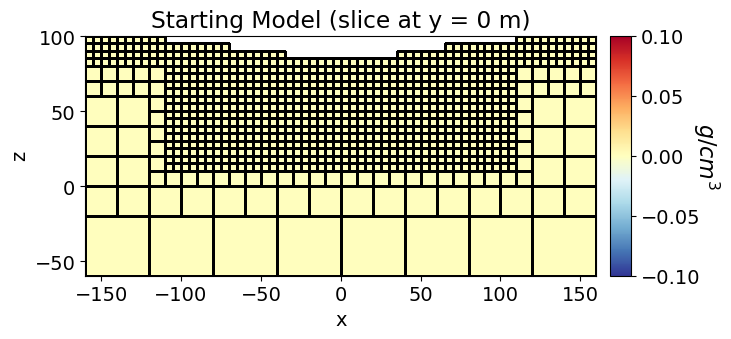

In [30]:
# Map for ignoring inactive cells when plotting
tree_plotting_map = maps.InjectActiveCells(tree_mesh, active_tree_cells, np.nan)


fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=-0.1, vmax=0.1)
tree_mesh.plot_slice(
    tree_plotting_map * starting_tree_model,
    normal="Y",
    ax=ax1,
    ind=int(tree_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title("Starting Model (slice at y = 0 m)")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

Define the Forward Simulation

In [31]:
simulation_irls = gravity.simulation.Simulation3DIntegral(
    survey=survey, mesh=tree_mesh, rhoMap=tree_model_map, active_cells=active_tree_cells
)

Define Data Misfit

In [32]:
dmis_irls = data_misfit.L2DataMisfit(data=new_data_object, simulation=simulation_irls)

Define the Regularization

In [33]:
reg_irls = regularization.Sparse(
    tree_mesh,
    active_cells=active_tree_cells,
    alpha_s=dh**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_tree_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

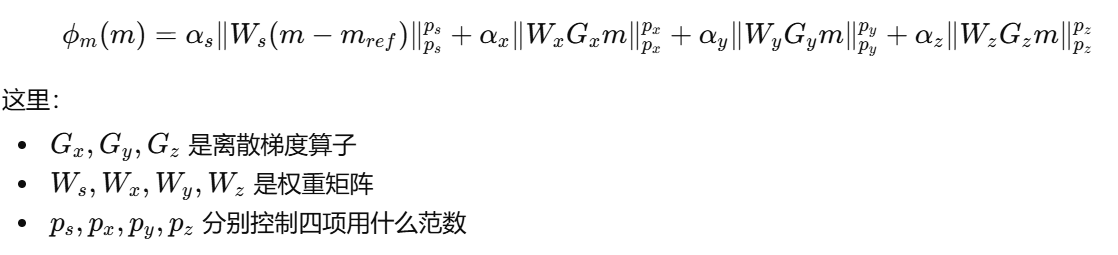

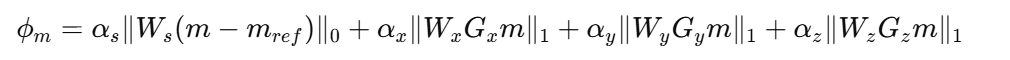

Define the Optimization Algorithm

In [34]:
opt_irls = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

Define the Inverse Problem

In [35]:
inv_prob_irls = inverse_problem.BaseInvProblem(dmis_irls, reg_irls, opt_irls)

Provide Inversion Directives

In [41]:
sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
]

Define and Run the Inversion

In [42]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_tree_model = inv_irls.run(starting_tree_model)

The callback on the ProjectedGNCG minimizer was replaced.

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  2.26e+05  1.08e+05  3.16e-07  1.08e+05                         10       4.24e-01     4.67e+02              
   1  2.26e+05  7.04e+04  7.25e-02  8.68e+04    2.09e+02      0      9        8.87e-03     8.96e+03              
   2  1.13e+05  5.10e+04  1.97e-01  7.33e+04    2.08e+02      0      9        7.02e-03     2.26e+03              
   3  5.65e+04  3.12e+04  4.49e-01  5.65e+04    2.07e+02      0      8        9.93e-03     2.41e+03              
   4  2.82e+04  1.58e+04  8.32e-01  3.93e+04    2.06e+02      0      8        7.87e-03     1.31e+03     

Plot the Data Misfit

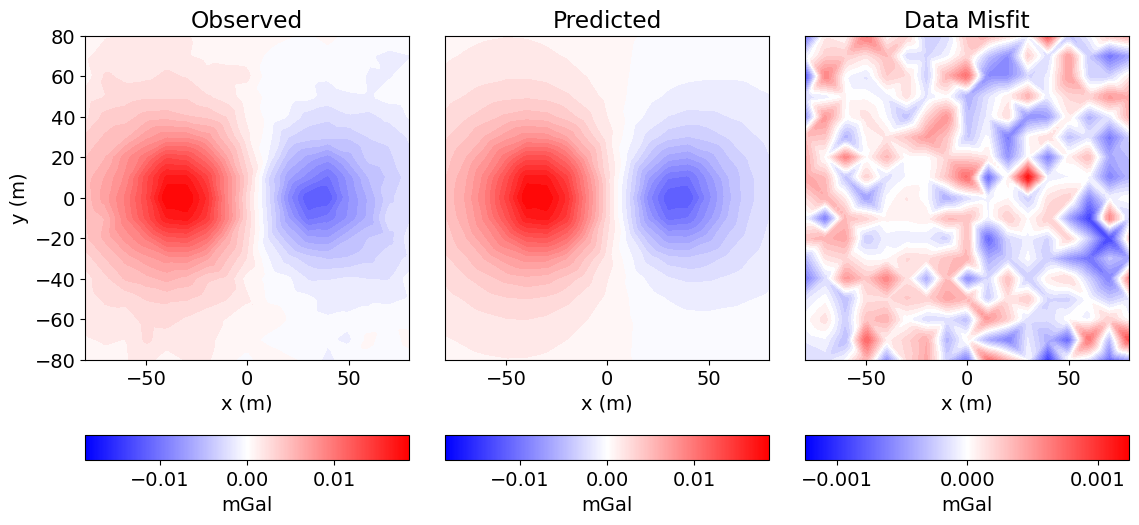

In [43]:
# Predicted data with final recovered model.
dpred_new = inv_prob_irls.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_new, dobs - dpred_new]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["mGal", "mGal", "mGal"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_new))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].ax.locator_params(nbins=3)
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

## Plot True, L2 and IRLS Models

In [44]:
# Recreate True Model on a Tensor Mesh
background_density = 0.0
block_density = -0.2
sphere_density = 0.2

true_model = background_density * np.ones(n_tensor_active)

ind_block = model_builder.get_indices_block(
    [-50, -15, 50], [-20, 15, 70], tensor_mesh.cell_centers[active_tensor_cells]
)
true_model[ind_block] = block_density

ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, 60.0], 14.0, tensor_mesh.cell_centers[active_tensor_cells]
)
true_model[ind_sphere] = sphere_density

C:\Users\30562\AppData\Local\Temp\ipykernel_40772\2978540076.py:8: BreakingChangeWarning: Since SimPEG v0.25.0, the 'get_indices_block' function returns a single array with the cell indices, instead of a tuple with a single element. This means that we don't need to unpack the tuple anymore to access to the cell indices.
If you were using this function as in:

    ind = get_indices_block(p0, p1, mesh.cell_centers)[0]

Make sure you update it to:

    ind = get_indices_block(p0, p1, mesh.cell_centers)

To hide this warning, add this to your script or notebook:

    import warnings
    from simpeg.utils import BreakingChangeWarning

    warnings.filterwarnings(action='ignore', category=BreakingChangeWarning)

  ind_block = model_builder.get_indices_block(


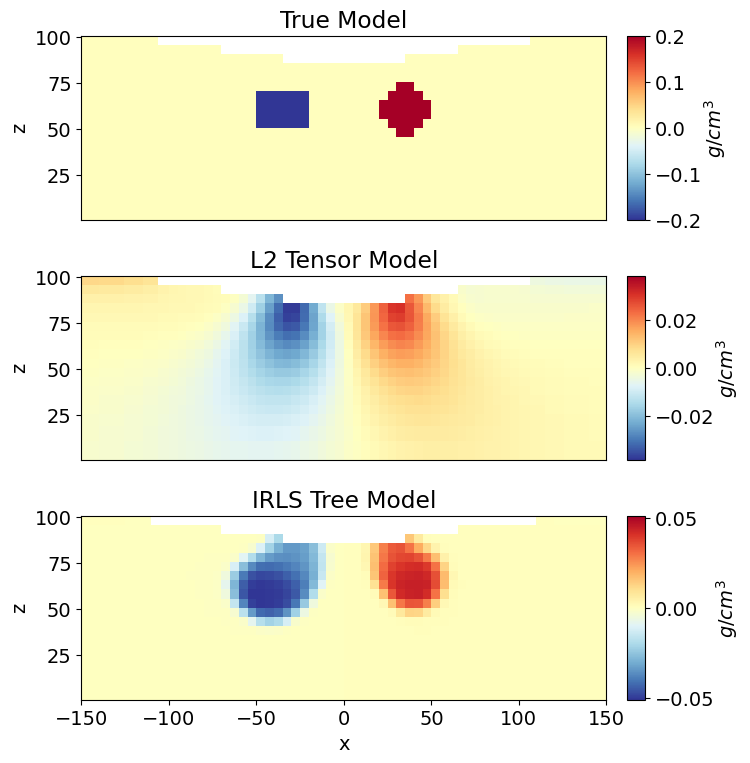

In [45]:
# Plot all models
mesh_list = [tensor_mesh, tensor_mesh, tree_mesh]
ind_list = [active_tensor_cells, active_tensor_cells, active_tree_cells]
model_list = [true_model, recovered_tensor_model, recovered_tree_model]
title_list = ["True Model", "L2 Tensor Model", "IRLS Tree Model"]
cplot = 3 * [None]
cbar = 3 * [None]
norm = 3 * [None]

fig = plt.figure(figsize=(7, 8))
ax1 = [fig.add_axes([0.1, 0.7 - 0.3 * ii, 0.75, 0.23]) for ii in range(0, 3)]
ax2 = [fig.add_axes([0.88, 0.7 - 0.3 * ii, 0.025, 0.23]) for ii in range(0, 3)]

for ii, mesh in enumerate(mesh_list):
    plotting_map = maps.InjectActiveCells(mesh, ind_list[ii], np.nan)
    max_abs = np.max(np.abs(model_list[ii]))
    norm[ii] = mpl.colors.Normalize(vmin=-max_abs, vmax=max_abs)

    cplot[ii] = mesh.plot_slice(
        plotting_map * model_list[ii],
        normal="Y",
        ax=ax1[ii],
        ind=int(mesh.shape_cells[1] / 2),
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm[ii]},
    )
    ax1[ii].set_xlim([-150, 150])
    ax1[ii].set_ylim([topo_xyz[:, -1].max() - 100, topo_xyz[:, -1].max()])
    if ii < 2:
        ax1[ii].set_xlabel("")
        ax1[ii].set_xticks([])
    ax1[ii].set_title(title_list[ii])

    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.RdYlBu_r
    )
    cbar[ii].set_label("$g/cm^3$", labelpad=0)